# Modelo de Riesgo Crediticio — Créditos para Cirugías Plásticas

**Proyecto Final — Modelos de Crédito | ITESO**
**Profesor:** Rodolfo Slay Ramos

---

**Objetivo:** Construir un modelo de crédito para financiar cirugías estéticas en Guadalajara, Jalisco, estimando:
- **PD** (Probability of Default) — Regresión Logística + Random Forest
- **LGD** (Loss Given Default) — Ridge Regression + Random Forest Regressor
- **EL** (Expected Loss) = PD × LGD × EAD

**Dataset:** LendingClub 2007–2015 (~249K préstamos con `purpose = credit_card`)

> **¿Por qué LendingClub?** Los préstamos de refinanciamiento de tarjeta de crédito comparten la misma estructura de riesgo que un crédito para cirugía estética: ambos son créditos al consumo **no garantizados**, sin colateral, con plazo fijo y cuotas mensuales. El modelo PD se entrena sobre estos datos reales y luego se aplica a solicitudes simuladas de cirugías plásticas.

---
### Estructura del notebook
1. Librerías e importaciones
2. Carga y exploración de datos (EDA)
3. Preparación de datos (PD y LGD)
4. Modelo PD — Clasificación binaria
5. Modelo LGD — Regresión
6. Pérdida Esperada (EL = PD × LGD × EAD)
7. Resultados y análisis final
8. **Aplicación Práctica — Simulador de crédito para cirugías**
9. **Simulación masiva — 10,000 solicitudes con P&L y ROE**


## 1. Librerías e importaciones

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


## 2. Carga y exploración de datos (EDA)

In [2]:
def cargar_datos(ruta: str) -> pd.DataFrame:
    """Carga el dataset de LendingClub desde un archivo CSV."""
    df = pd.read_csv(ruta, encoding="latin-1")
    print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
    return df

RUTA_DATOS = 'AAlendingclub_credit_card-limpio.csv'
df_raw = cargar_datos(RUTA_DATOS)


Dataset cargado: 249,343 filas x 40 columnas


In [3]:
def explorar_datos(df: pd.DataFrame) -> None:
    """Resumen exploratorio: tipos, nulos, estadísticas."""
    display(df.head())
    print('\nTipos de datos')
    print(df.dtypes.to_string())
    print('\nValores nulos (%)')
    nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    print(nulos[nulos > 0].round(2).to_string())
    print('\nEstadísticas descriptivas')
    display(df.describe().T.round(2))

explorar_datos(df_raw)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,collection_recovery_fee,acc_now_delinq,bc_util,mort_acc,num_tl_90g_dpd_24m,pct_tl_nvr_dlq,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort
0,5550,5550,5550.0,36 months,15.02,192.45,C,C3,Director COE,10+ years,...,0.0,0,64.0,6,0,100.0,0,0,831687,185378
1,6000,6000,6000.0,36 months,13.56,203.79,C,C1,Assistant Director,10+ years,...,0.0,0,90.8,1,0,100.0,0,0,117242,91535
2,5500,5500,5500.0,36 months,22.35,211.05,D,D5,NaN,< 1 year,...,0.0,0,94.4,3,1,84.6,0,0,243452,18185
3,28000,28000,28000.0,60 months,11.31,613.13,B,B3,Consultant,2 years,...,0.0,0,55.9,1,0,100.0,0,0,259435,65636
4,11200,11200,11200.0,36 months,8.19,351.95,A,A4,Job Coach Supervisor,10+ years,...,0.0,0,24.7,4,0,100.0,0,0,345654,78795



Tipos de datos
loan_amnt                    int64
funded_amnt                  int64
funded_amnt_inv            float64
term                        object
int_rate                   float64
installment                float64
grade                       object
sub_grade                   object
emp_title                   object
emp_length                  object
home_ownership              object
annual_inc                 float64
verification_status         object
issue_d                     object
loan_status                 object
purpose                     object
addr_state                  object
dti                        float64
delinq_2yrs                  int64
earliest_cr_line            object
inq_last_6mths               int64
mths_since_last_delinq     float64
mths_since_last_record     float64
open_acc                     int64
pub_rec                      int64
revol_bal                    int64
revol_util                 float64
total_acc                    int64
init

,count,mean,std,min,25%,50%,75%,max
loan_amnt,249343.0,15496.25,9157.70,1000.00,8975.00,13200.00,20000.00,40000.00
funded_amnt,249343.0,15496.25,9157.70,1000.00,8975.00,13200.00,20000.00,40000.00
funded_amnt_inv,249343.0,15491.32,9156.68,750.00,8900.00,13200.00,20000.00,40000.00
int_rate,249343.0,11.38,4.39,5.31,7.89,10.75,13.67,30.99
installment,249343.0,452.07,262.47,30.12,262.14,379.06,595.83,1597.60
annual_inc,249343.0,79753.44,81159.05,0.00,47000.00,66000.00,95000.00,9000000.00
dti,249099.0,19.46,15.62,0.00,12.28,18.22,25.01,999.00
delinq_2yrs,249343.0,0.24,0.75,0.00,0.00,0.00,0.00,23.00
inq_last_6mths,249343.0,0.47,0.77,0.00,0.00,0.00,1.00,5.00
mths_since_last_delinq,109402.0,35.90,21.94,0.00,17.00,33.00,52.00,161.00


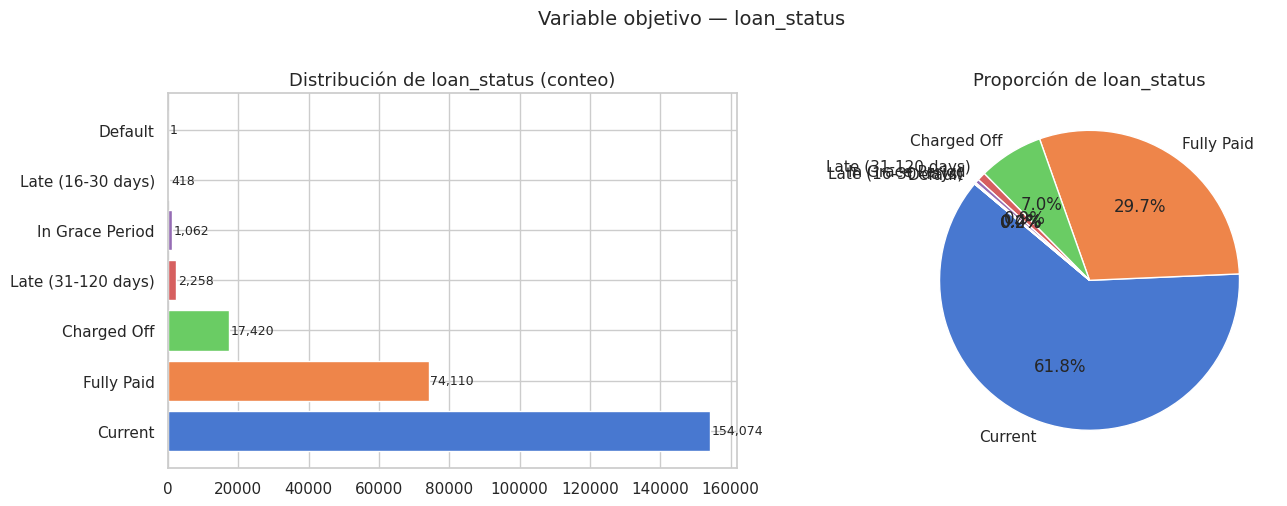

In [4]:
def graficar_distribucion_objetivo(df, col='loan_status'):
    """Distribución de la variable objetivo."""
    conteo = df[col].value_counts()
    colores = sns.color_palette('muted', len(conteo))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(conteo.index, conteo.values, color=colores)
    axes[0].set_title('Distribución de loan_status (conteo)')
    for i, v in enumerate(conteo.values):
        axes[0].text(v + 500, i, f'{v:,}', va='center', fontsize=9)
    axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
                colors=colores, startangle=140)
    axes[1].set_title('Proporción de loan_status')
    plt.suptitle('Variable objetivo — loan_status', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

graficar_distribucion_objetivo(df_raw)


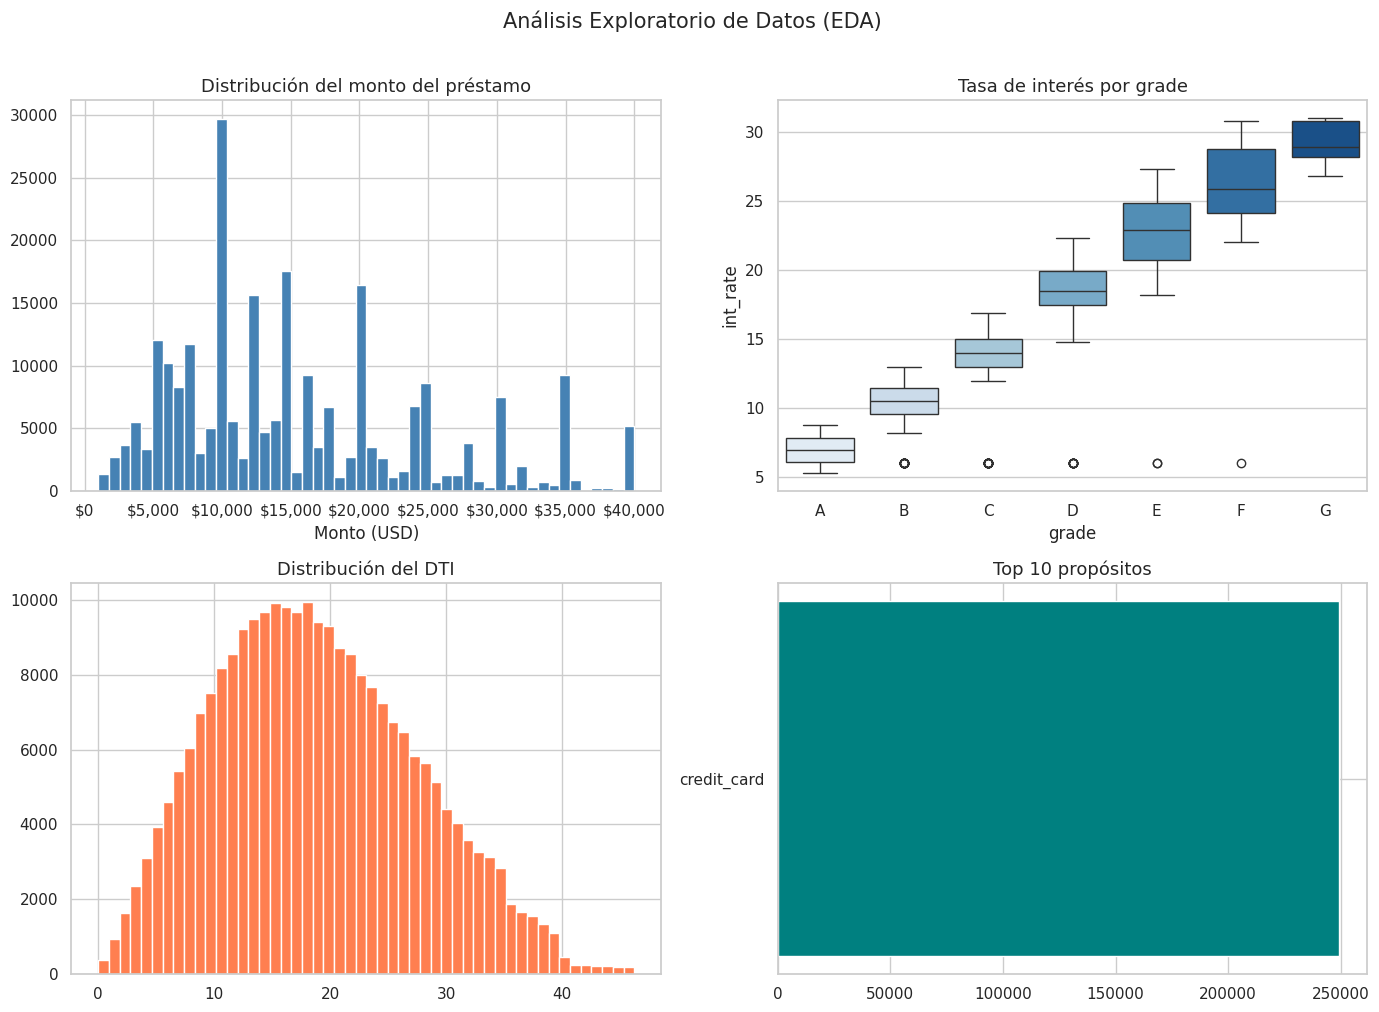

In [5]:
def graficar_eda(df):
    """Visualizaciones exploratorias clave."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0, 0].hist(df['loan_amnt'], bins=50, color='steelblue', edgecolor='white')
    axes[0, 0].set_title('Distribución del monto del préstamo')
    axes[0, 0].set_xlabel('Monto (USD)')
    axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    orden = sorted(df['grade'].dropna().unique())
    sns.boxplot(data=df, x='grade', y='int_rate', order=orden, ax=axes[0, 1], palette='Blues')
    axes[0, 1].set_title('Tasa de interés por grade')
    dti = df['dti'].dropna()
    dti = dti[dti < dti.quantile(0.99)]
    axes[1, 0].hist(dti, bins=50, color='coral', edgecolor='white')
    axes[1, 0].set_title('Distribución del DTI')
    top = df['purpose'].value_counts().head(10)
    axes[1, 1].barh(top.index[::-1], top.values[::-1], color='teal')
    axes[1, 1].set_title('Top 10 propósitos')
    plt.suptitle('Análisis Exploratorio de Datos (EDA)', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

graficar_eda(df_raw)


## 3. Preparación de datos

### 3.1 Variables objetivo

**PD:** `0` = Fully Paid, `1` = Charged Off / Late / In Grace Period / Default
**LGD:** `1 - (recoveries / funded_amnt)`, solo para defaults


In [6]:
def crear_variable_pd(df):
    """Variable objetivo binaria para PD."""
    estados_default = ['Charged Off', 'Late (31-120 days)', 'Late (16-30 days)',
                       'In Grace Period', 'Default']
    estados_validos = ['Fully Paid'] + estados_default
    df_pd = df[df['loan_status'].isin(estados_validos)].copy()
    df_pd['target_pd'] = df_pd['loan_status'].apply(lambda x: 1 if x in estados_default else 0)
    total = len(df_pd)
    defaults = df_pd['target_pd'].sum()
    print(f'Dataset PD: {total:,} préstamos')
    print(f'  No default (0): {total - defaults:,} ({(total - defaults)/total*100:.1f}%)')
    print(f'  Default    (1): {defaults:,} ({defaults/total*100:.1f}%)')
    return df_pd

def crear_variable_lgd(df_pd):
    """Variable objetivo continua para LGD (solo defaults)."""
    df_def = df_pd[df_pd['target_pd'] == 1].copy()
    df_def['target_lgd'] = 1 - (df_def['recoveries'] / df_def['funded_amnt'].replace(0, np.nan))
    df_def['target_lgd'] = df_def['target_lgd'].clip(0, 1)
    print(f'Dataset LGD: {len(df_def):,} préstamos en default')
    print(f'  LGD media:   {df_def["target_lgd"].mean():.4f}')
    print(f'  LGD mediana: {df_def["target_lgd"].median():.4f}')
    return df_def

df_pd = crear_variable_pd(df_raw)
df_lgd = crear_variable_lgd(df_pd)


Dataset PD: 95,269 préstamos
  No default (0): 74,110 (77.8%)
  Default    (1): 21,159 (22.2%)
Dataset LGD: 21,159 préstamos en default
  LGD media:   0.9437
  LGD mediana: 1.0000


### 3.2 Limpieza y transformación

In [7]:
def limpiar_term(df):
    df = df.copy()
    df['term'] = df['term'].str.extract(r'(\d+)').astype(float)
    return df

def limpiar_emp_length(df):
    df = df.copy()
    mapeo = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
             '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
             '8 years': 8, '9 years': 9, '10+ years': 10}
    df['emp_length'] = df['emp_length'].map(mapeo).fillna(-1)
    return df

def limpiar_earliest_cr_line(df):
    df = df.copy()
    df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
    df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
    df['cr_hist_years'] = ((df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25).clip(lower=0)
    df = df.drop(columns=['earliest_cr_line', 'issue_d'])
    return df

def imputar_nulos(df):
    df = df.copy()
    for col in ['mths_since_last_delinq', 'mths_since_last_record']:
        if col in df.columns:
            df[col] = df[col].fillna(-1)
    if 'cr_hist_years' in df.columns:
        df['cr_hist_years'] = df['cr_hist_years'].fillna(df['cr_hist_years'].median())
    cols_num = df.select_dtypes(include=[np.number]).columns
    for col in cols_num:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
    return df

def codificar_categoricas(df, cols_ohe):
    df = df.copy()
    cols_existentes = [c for c in cols_ohe if c in df.columns]
    df = pd.get_dummies(df, columns=cols_existentes, drop_first=True)
    for col in df.select_dtypes(include=['bool']).columns:
        df[col] = df[col].astype(int)
    return df

def preparar_datos(df, target_col):
    """Pipeline completo de limpieza."""
    cols_drop = ['loan_status', 'emp_title', 'addr_state', 'purpose', 'initial_list_status']
    cols_drop = [c for c in cols_drop if c in df.columns and c != target_col]
    df = df.drop(columns=cols_drop)
    df = limpiar_term(df)
    df = limpiar_emp_length(df)
    df = limpiar_earliest_cr_line(df)
    df = imputar_nulos(df)
    df = codificar_categoricas(df, ['grade', 'sub_grade', 'home_ownership', 'verification_status'])
    print(f'Dataset preparado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
    print(f'Nulos restantes: {df.isnull().sum().sum()}')
    return df

print('Preparando dataset PD...')
df_pd_prep = preparar_datos(df_pd, 'target_pd')

print('\nPreparando dataset LGD...')
df_lgd_prep = preparar_datos(df_lgd, 'target_lgd')
for c in ['recoveries', 'collection_recovery_fee']:
    if c in df_lgd_prep.columns:
        df_lgd_prep = df_lgd_prep.drop(columns=[c])


Preparando dataset PD...
Dataset preparado: 95,269 filas x 76 columnas
Nulos restantes: 0

Preparando dataset LGD...
Dataset preparado: 21,159 filas x 77 columnas
Nulos restantes: 0


### 3.3 Split train / test

In [8]:
def hacer_split(df, col_target, test_size=0.2, stratify=True, seed=SEED):
    X = df.drop(columns=[col_target])
    y = df[col_target]
    strat = y if stratify else None
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size,
                                                random_state=seed, stratify=strat)
    print(f'  Train: {X_tr.shape[0]:,} | Test: {X_te.shape[0]:,}')
    return X_tr, X_te, y_tr, y_te

print('Split PD')
X_train_pd, X_test_pd, y_train_pd, y_test_pd = hacer_split(df_pd_prep, 'target_pd')
print('\nSplit LGD')
X_train_lgd, X_test_lgd, y_train_lgd, y_test_lgd = hacer_split(df_lgd_prep, 'target_lgd', stratify=False)

scaler = StandardScaler()
X_train_pd_sc = scaler.fit_transform(X_train_pd)
X_test_pd_sc = scaler.transform(X_test_pd)

scaler_lgd = StandardScaler()
X_train_lgd_sc = scaler_lgd.fit_transform(X_train_lgd)
X_test_lgd_sc = scaler_lgd.transform(X_test_lgd)
print('\nEscalado completado')


Split PD
  Train: 76,215 | Test: 19,054

Split LGD
  Train: 16,927 | Test: 4,232

Escalado completado


## 4. Modelo PD — Probabilidad de Default

Dos modelos: **Regresión Logística** (interpretable) vs **Random Forest** (ensemble).
Métricas: **AUC-ROC**, **Gini**, **KS**, validación cruzada 5-fold.


In [9]:
rl_pd = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED, solver='lbfgs')
rl_pd.fit(X_train_pd_sc, y_train_pd)
print('Regresión Logística entrenada')

rf_pd = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=50,
                                class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_pd.fit(X_train_pd, y_train_pd)
print('Random Forest entrenado')


Regresión Logística entrenada
Random Forest entrenado


In [10]:
def calcular_metricas_pd(nombre, modelo, X_test, y_test, escalado=False, scaler_obj=None):
    X = scaler_obj.transform(X_test) if escalado else X_test
    proba = modelo.predict_proba(X)[:, 1]
    y_pred = modelo.predict(X)
    auc = roc_auc_score(y_test, proba)
    gini = 2 * auc - 1
    df_ks = pd.DataFrame({'prob': proba, 'real': y_test.values}).sort_values('prob', ascending=False)
    df_ks['cum_ev'] = df_ks['real'].cumsum() / df_ks['real'].sum()
    df_ks['cum_ne'] = (1 - df_ks['real']).cumsum() / (1 - df_ks['real']).sum()
    ks = (df_ks['cum_ev'] - df_ks['cum_ne']).abs().max()
    print(f'\n{nombre}: AUC={auc:.4f} | Gini={gini:.4f} | KS={ks:.4f}')
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
    return {'nombre': nombre, 'auc': auc, 'gini': gini, 'ks': ks, 'proba': proba}

res_rl = calcular_metricas_pd('Regresión Logística', rl_pd, X_test_pd, y_test_pd, True, scaler)
res_rf = calcular_metricas_pd('Random Forest', rf_pd, X_test_pd, y_test_pd)



Regresión Logística: AUC=0.8587 | Gini=0.7175 | KS=0.5590
              precision    recall  f1-score   support

  No Default       0.90      0.90      0.90     14822
     Default       0.65      0.65      0.65      4232

    accuracy                           0.84     19054
   macro avg       0.77      0.78      0.78     19054
weighted avg       0.84      0.84      0.84     19054


Random Forest: AUC=0.8587 | Gini=0.7174 | KS=0.5549
              precision    recall  f1-score   support

  No Default       0.90      0.91      0.90     14822
     Default       0.67      0.64      0.65      4232

    accuracy                           0.85     19054
   macro avg       0.78      0.78      0.78     19054
weighted avg       0.85      0.85      0.85     19054



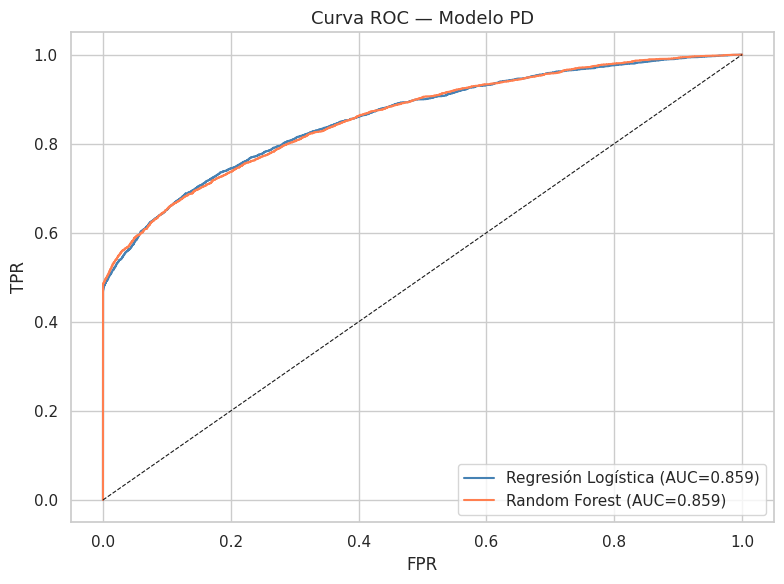

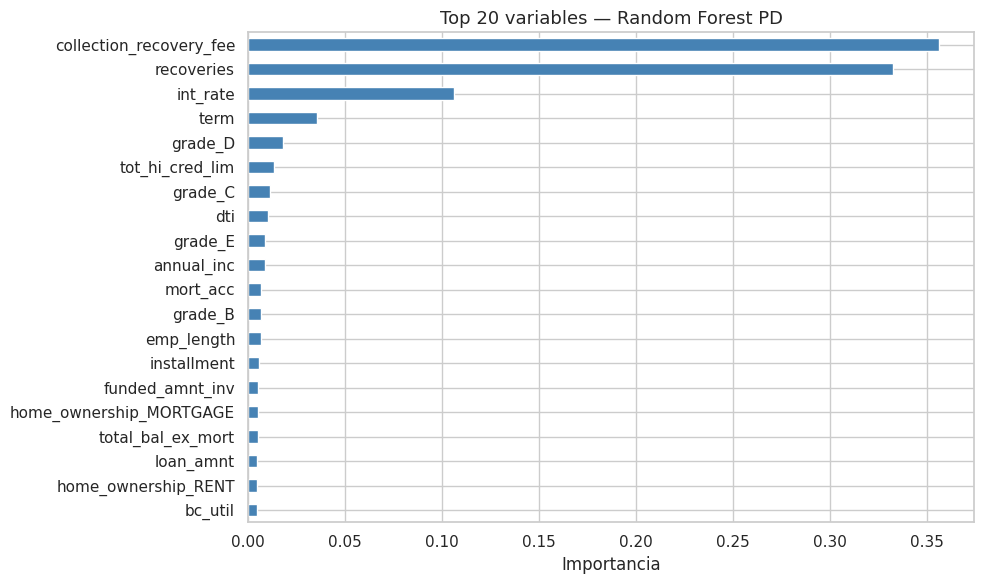

In [11]:
# Curva ROC
plt.figure(figsize=(8, 6))
for res, color in [(res_rl, 'steelblue'), (res_rf, 'coral')]:
    fpr, tpr, _ = roc_curve(y_test_pd, res['proba'])
    plt.plot(fpr, tpr, color=color, label=f"{res['nombre']} (AUC={res['auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Curva ROC — Modelo PD')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

# Feature Importance
imp = pd.Series(rf_pd.feature_importances_, index=X_test_pd.columns)
imp.sort_values(ascending=False).head(20)[::-1].plot(kind='barh', color='steelblue', figsize=(10, 6))
plt.title('Top 20 variables — Random Forest PD'); plt.xlabel('Importancia')
plt.tight_layout(); plt.show()


In [12]:
# Validación cruzada 5-fold
for nombre, modelo, X in [('Regresión Logística', rl_pd, X_train_pd_sc),
                           ('Random Forest', rf_pd, X_train_pd)]:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(modelo, X, y_train_pd, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{nombre}: AUC media = {scores.mean():.4f} ± {scores.std():.4f}')


Regresión Logística: AUC media = 0.8575 ± 0.0027
Random Forest: AUC media = 0.8561 ± 0.0019


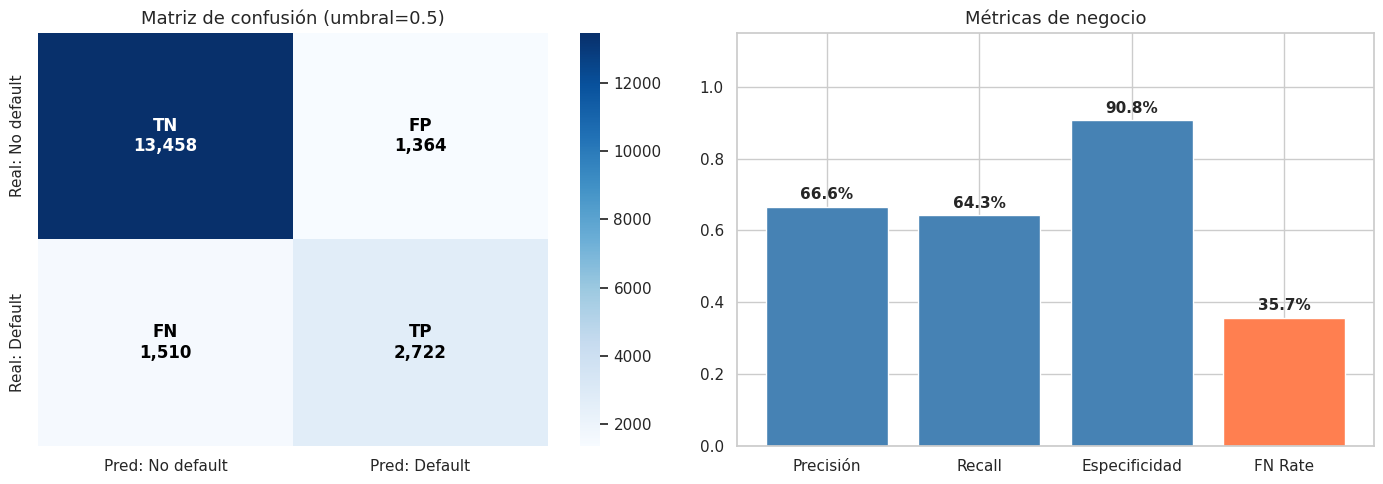

In [13]:
# Matriz de confusión
proba_rf = res_rf['proba']
y_pred = (proba_rf >= 0.5).astype(int)
cm = confusion_matrix(y_test_pd, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[0],
            xticklabels=['Pred: No default', 'Pred: Default'],
            yticklabels=['Real: No default', 'Real: Default'])
for i in range(2):
    for j in range(2):
        txt = [['TN', 'FP'], ['FN', 'TP']][i][j] + f'\n{cm[i,j]:,}'
        color = 'white' if cm[i,j] > cm.max() * 0.5 else 'black'
        axes[0].text(j+0.5, i+0.5, txt, ha='center', va='center', fontsize=12, fontweight='bold', color=color)
axes[0].set_title('Matriz de confusión (umbral=0.5)')

prec = tp/(tp+fp) if (tp+fp) > 0 else 0
rec = tp/(tp+fn) if (tp+fn) > 0 else 0
esp = tn/(tn+fp) if (tn+fp) > 0 else 0
fnr = fn/(tp+fn) if (tp+fn) > 0 else 0
bars = axes[1].bar(['Precisión', 'Recall', 'Especificidad', 'FN Rate'],
                    [prec, rec, esp, fnr], color=['steelblue','steelblue','steelblue','coral'])
for b, v in zip(bars, [prec, rec, esp, fnr]):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.1%}',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 1.15); axes[1].set_title('Métricas de negocio')
plt.tight_layout(); plt.show()


## 5. Modelo LGD — Loss Given Default

In [14]:
ridge_lgd = Ridge(alpha=1.0).fit(X_train_lgd_sc, y_train_lgd)
rf_lgd = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=30,
                                random_state=SEED, n_jobs=-1).fit(X_train_lgd, y_train_lgd)

for nombre, modelo, X, esc in [('Ridge', ridge_lgd, X_test_lgd, True),
                                 ('RF Reg.', rf_lgd, X_test_lgd, False)]:
    Xt = scaler_lgd.transform(X) if esc else X
    yp = modelo.predict(Xt).clip(0, 1)
    print(f'{nombre}: RMSE={np.sqrt(mean_squared_error(y_test_lgd, yp)):.4f} | '
          f'MAE={mean_absolute_error(y_test_lgd, yp):.4f} | R²={r2_score(y_test_lgd, yp):.4f}')

LGD_PROMEDIO = df_lgd['target_lgd'].mean()
print(f'\nLGD promedio del portafolio: {LGD_PROMEDIO:.4f}')


Ridge: RMSE=0.0840 | MAE=0.0581 | R²=0.0100
RF Reg.: RMSE=0.0841 | MAE=0.0589 | R²=0.0069

LGD promedio del portafolio: 0.9437


## 6. Pérdida Esperada (EL = PD × LGD × EAD)

In [15]:
pd_pred = rf_pd.predict_proba(X_test_pd)[:, 1]
lgd_proxy = LGD_PROMEDIO
ead = df_pd.loc[X_test_pd.index, 'funded_amnt'].values

el_usd = pd_pred * lgd_proxy * ead
df_el = pd.DataFrame({'pd_pred': pd_pred, 'lgd': lgd_proxy, 'ead': ead, 'el_usd': el_usd})

print(f'EL media por préstamo: ${df_el["el_usd"].mean():,.2f} USD')
print(f'EL total portafolio:   ${df_el["el_usd"].sum():,.0f} USD')
print(f'PD media predicha:     {df_el["pd_pred"].mean()*100:.2f}%')


EL media por préstamo: $5,679.55 USD
EL total portafolio:   $108,218,075 USD
PD media predicha:     39.17%


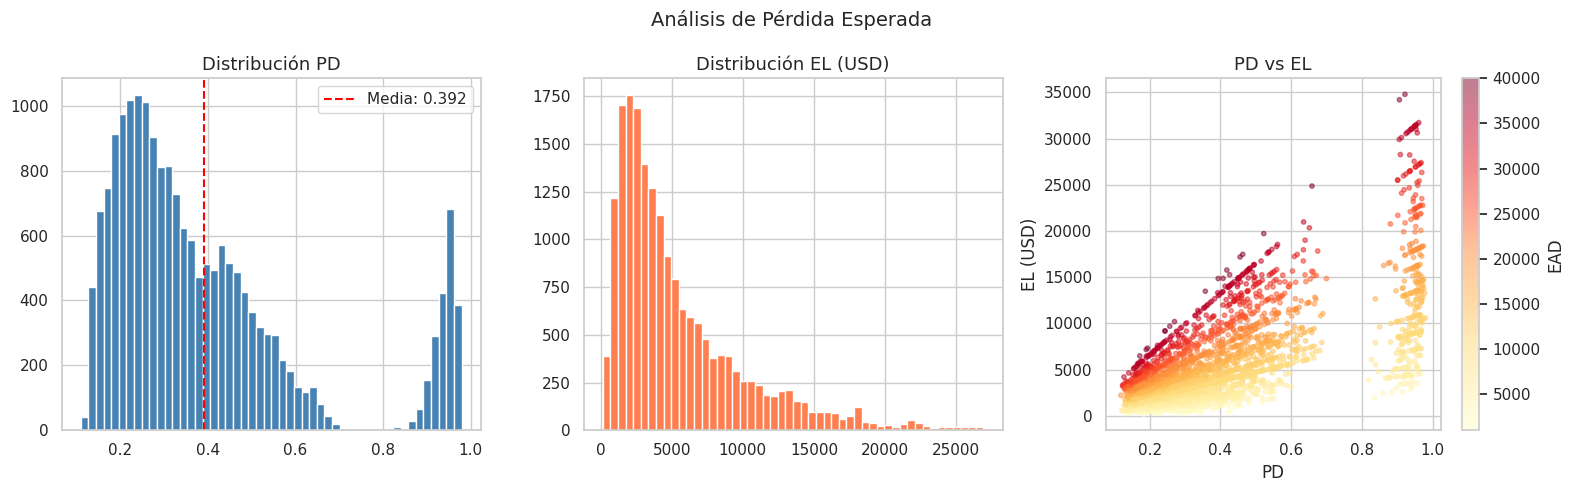

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(df_el['pd_pred'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df_el['pd_pred'].mean(), color='red', linestyle='--',
                label=f'Media: {df_el["pd_pred"].mean():.3f}')
axes[0].set_title('Distribución PD'); axes[0].legend()

el_f = df_el['el_usd'][df_el['el_usd'] < df_el['el_usd'].quantile(0.99)]
axes[1].hist(el_f, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribución EL (USD)')

idx = np.random.choice(len(df_el), min(3000, len(df_el)), replace=False)
sc = axes[2].scatter(df_el['pd_pred'].iloc[idx], df_el['el_usd'].iloc[idx],
                     c=df_el['ead'].iloc[idx], cmap='YlOrRd', alpha=0.5, s=10)
plt.colorbar(sc, ax=axes[2], label='EAD')
axes[2].set_xlabel('PD'); axes[2].set_ylabel('EL (USD)'); axes[2].set_title('PD vs EL')
plt.suptitle('Análisis de Pérdida Esperada', fontsize=14)
plt.tight_layout(); plt.show()


## 7. Resumen ejecutivo del modelo

In [17]:
print('=' * 60)
print('  RESUMEN EJECUTIVO — MODELO DE RIESGO CREDITICIO')
print('=' * 60)
print(f'\nModelo PD:')
print(f'  {"Modelo":<25} {"AUC":>8} {"Gini":>8} {"KS":>8}')
print(f'  {"-"*25} {"-"*8} {"-"*8} {"-"*8}')
for r in [res_rl, res_rf]:
    print(f'  {r["nombre"]:<25} {r["auc"]:>8.4f} {r["gini"]:>8.4f} {r["ks"]:>8.4f}')
print(f'\nLGD promedio: {LGD_PROMEDIO:.4f}')
print(f'\nPérdida Esperada:')
print(f'  EL media/préstamo: ${df_el["el_usd"].mean():,.2f}')
print(f'  EL total:          ${df_el["el_usd"].sum():,.0f}')
print(f'  PD media predicha: {df_el["pd_pred"].mean()*100:.2f}%')


  RESUMEN EJECUTIVO — MODELO DE RIESGO CREDITICIO

Modelo PD:
  Modelo                         AUC     Gini       KS
  ------------------------- -------- -------- --------
  Regresión Logística         0.8587   0.7175   0.5590
  Random Forest               0.8587   0.7174   0.5549

LGD promedio: 0.9437

Pérdida Esperada:
  EL media/préstamo: $5,679.55
  EL total:          $108,218,075
  PD media predicha: 39.17%


---
## 8. Aplicación Práctica — Simulador de Crédito para Cirugías

### 8.1 Parámetros del producto

**Producto:** Crédito personal para cirugía estética, plazo fijo 12 meses.
**Seguro de vida:** $4,000 MXN por crédito (prima anual, fuentes: MAPFRE, BBVA, GNP).
**Tasas:** Basadas en las tasas promedio por grade del dataset LendingClub.


In [18]:
# ============================================================
# CATÁLOGO DE CIRUGÍAS — Guadalajara, Jalisco
# Fuente: Consulta directa con cirujano plástico certificado
# ============================================================
TC = 17.17  # Tipo de cambio MXN/USD

catalogo_cirugias = {
    "Rinoplastia":                  80_000 / TC,
    "Aumento de Busto":             85_000 / TC,
    "Liposucción y Escultura":     120_000 / TC,
    "Bypass Gástrico (Bariátrica)":140_000 / TC,
    "Mommy Makeover":              120_000 / TC,
    "Abdominoplastia":             120_000 / TC,
    "Mastopexia":                  100_000 / TC,
}

# ============================================================
# AJUSTE POR PRIMA DE PAÍS (México vs EE.UU.)
# ============================================================
# Las tasas de LendingClub reflejan el costo del dinero en EE.UU.
# (Fed Funds Rate 0.25-2.50% durante 2015-2018). En México, la
# TIIE durante el mismo periodo fue 3-7%, y actualmente ~10%.
# La diferencia de tasas de referencia es aproximadamente 3.5%.
# Este spread se suma a cada tasa por grade para reflejar el
# costo real de operar en el mercado mexicano.
# Fuente: Banco de México (TIIE), Federal Reserve (Fed Funds Rate)

PRIMA_PAIS_MX = 3.5  # puntos porcentuales adicionales

# Tasas base de LendingClub + prima por país México
tasas_base_lc = {'A': 6.9, 'B': 10.4, 'C': 14.1, 'D': 18.6, 'E': 22.8, 'F': 26.3, 'G': 29.2}
tasas_por_grade = {g: t + PRIMA_PAIS_MX for g, t in tasas_base_lc.items()}

# ============================================================
# SEGURO DE VIDA — Proporcional al monto del crédito
# ============================================================
# En vez de un costo fijo de $233 USD (que se come las ganancias
# en préstamos pequeños), usamos una prima proporcional al monto.
# Una prima de 1.5% sobre el monto del crédito es competitiva
# con el mercado mexicano de seguros de vida temporal:
# - Cirugía de $80K MXN → seguro de $1,200 MXN (antes $4,000)
# - Cirugía de $140K MXN → seguro de $2,100 MXN (antes $4,000)
# Fuentes: MAPFRE, BBVA Seguros, GNP, Condusef 2026

TASA_SEGURO = 0.015  # 1.5% del monto del crédito

# ============================================================
# COMISIÓN DE APERTURA (Origination Fee)
# ============================================================
# LendingClub cobraba 1-5% como comisión de apertura.
# Usamos un 2% fijo que se cobra al momento de otorgar el
# crédito. Este ingreso se materializa antes de cualquier riesgo.

COMISION_APERTURA = 0.02  # 2% del monto

PLAZO_MESES = 12

print('PARÁMETROS DEL PRODUCTO')
print('=' * 55)
print(f'Prima país México:     +{PRIMA_PAIS_MX}% sobre tasas LendingClub')
print(f'Seguro de vida:        {TASA_SEGURO:.1%} del monto del crédito')
print(f'Comisión de apertura:  {COMISION_APERTURA:.0%} del monto')
print(f'Plazo:                 {PLAZO_MESES} meses')

print(f'\nTASAS POR GRADE (con prima México):')
print(f"  {'Grade':<6} {'LC Base':>8} {'+ Prima':>8} {'= Final':>8}")
for g in ['A','B','C','D','E','F','G']:
    print(f"  {g:<6} {tasas_base_lc[g]:>7.1f}% {'+'+str(PRIMA_PAIS_MX):>7}% {tasas_por_grade[g]:>7.1f}%")

print(f'\nCATÁLOGO DE CIRUGÍAS')
print(f"  {'Cirugía':<35} {'MXN':>12} {'USD':>10}")
print(f"  {'-'*35} {'-'*12} {'-'*10}")
for nombre, usd in catalogo_cirugias.items():
    print(f'  {nombre:<35} ${usd*TC:>10,.0f} ${usd:>8,.0f}')


PARÁMETROS DEL PRODUCTO
Prima país México:     +3.5% sobre tasas LendingClub
Seguro de vida:        1.5% del monto del crédito
Comisión de apertura:  2% del monto
Plazo:                 12 meses

TASAS POR GRADE (con prima México):
  Grade   LC Base  + Prima  = Final
  A          6.9%    +3.5%    10.4%
  B         10.4%    +3.5%    13.9%
  C         14.1%    +3.5%    17.6%
  D         18.6%    +3.5%    22.1%
  E         22.8%    +3.5%    26.3%
  F         26.3%    +3.5%    29.8%
  G         29.2%    +3.5%    32.7%

CATÁLOGO DE CIRUGÍAS
  Cirugía                                      MXN        USD
  ----------------------------------- ------------ ----------
  Rinoplastia                         $    80,000 $   4,659
  Aumento de Busto                    $    85,000 $   4,950
  Liposucción y Escultura             $   120,000 $   6,989
  Bypass Gástrico (Bariátrica)        $   140,000 $   8,154
  Mommy Makeover                      $   120,000 $   6,989
  Abdominoplastia                 

### 8.2 Motor de evaluación individual

In [19]:
def asignar_grade(pd_score):
    """Asigna grade A-G basado en la PD predicha."""
    if pd_score < 0.10:   return 'A'
    elif pd_score < 0.20: return 'B'
    elif pd_score < 0.30: return 'C'
    elif pd_score < 0.45: return 'D'
    elif pd_score < 0.60: return 'E'
    elif pd_score < 0.75: return 'F'
    else:                 return 'G'

def calcular_mensualidad(monto, tasa_anual_pct, plazo):
    """Mensualidad fija con fórmula de anualidad."""
    r = (tasa_anual_pct / 100) / 12
    if r == 0: return monto / plazo
    return monto * (r * (1 + r)**plazo) / ((1 + r)**plazo - 1)

def evaluar_paciente(nombre, cirugia, pd_score):
    """Evalúa una solicitud individual (con prima MX y seguro proporcional)."""
    monto_usd = catalogo_cirugias[cirugia]
    monto_mxn = monto_usd * TC
    grade = asignar_grade(pd_score)
    tasa = tasas_por_grade[grade]  # Ya incluye prima México
    aprobado = grade not in ['F', 'G']

    if aprobado:
        mens_usd = calcular_mensualidad(monto_usd, tasa, PLAZO_MESES)
        mens_mxn = mens_usd * TC
        total_mxn = mens_mxn * PLAZO_MESES
        interes_mxn = total_mxn - monto_mxn
        seguro_mxn = monto_mxn * TASA_SEGURO
        comision_mxn = monto_mxn * COMISION_APERTURA
        el_mxn = pd_score * LGD_PROMEDIO * monto_mxn
        eg_mxn = (1 - pd_score) * (interes_mxn + comision_mxn)
    else:
        mens_mxn = total_mxn = interes_mxn = eg_mxn = 0
        seguro_mxn = comision_mxn = 0
        el_mxn = pd_score * LGD_PROMEDIO * monto_mxn

    print(f"\n{'='*55}")
    print(f"  {nombre} — {cirugia}")
    print(f"{'='*55}")
    print(f"  Monto: ${monto_mxn:,.0f} MXN | PD: {pd_score:.0%} | Grade: {grade} | Tasa: {tasa:.1f}%")
    print(f"  Decisión: {'APROBADO' if aprobado else 'RECHAZADO'}")
    if aprobado:
        print(f"  Mensualidad: ${mens_mxn:,.0f} MXN | Total: ${total_mxn:,.0f} MXN")
        print(f"  Seguro: ${seguro_mxn:,.0f} MXN | Comisión: ${comision_mxn:,.0f} MXN")
        print(f"  EL: ${el_mxn:,.0f} MXN | EG: ${eg_mxn:,.0f} MXN")
    return {'paciente': nombre, 'cirugia': cirugia, 'monto_mxn': monto_mxn,
            'pd': pd_score, 'grade': grade, 'tasa': tasa, 'aprobado': aprobado,
            'mensualidad_mxn': mens_mxn, 'el_mxn': el_mxn, 'eg_mxn': eg_mxn}

pacientes = [
    ("María López",     "Rinoplastia",                   0.05),
    ("Carlos Ramírez",  "Liposucción y Escultura",       0.12),
    ("Ana Torres",      "Aumento de Busto",              0.22),
    ("Pedro Hernández", "Bypass Gástrico (Bariátrica)",  0.38),
    ("Laura Díaz",      "Mommy Makeover",                0.52),
    ("Roberto Sánchez", "Abdominoplastia",               0.68),
    ("Diana Morales",   "Mastopexia",                    0.80),
]

resultados_ind = [evaluar_paciente(n, c, p) for n, c, p in pacientes]



  María López — Rinoplastia
  Monto: $80,000 MXN | PD: 5% | Grade: A | Tasa: 10.4%
  Decisión: APROBADO
  Mensualidad: $7,048 MXN | Total: $84,578 MXN
  Seguro: $1,200 MXN | Comisión: $1,600 MXN
  EL: $3,775 MXN | EG: $5,869 MXN

  Carlos Ramírez — Liposucción y Escultura
  Monto: $120,000 MXN | PD: 12% | Grade: B | Tasa: 13.9%
  Decisión: APROBADO
  Mensualidad: $10,769 MXN | Total: $129,226 MXN
  Seguro: $1,800 MXN | Comisión: $2,400 MXN
  EL: $13,589 MXN | EG: $10,231 MXN

  Ana Torres — Aumento de Busto
  Monto: $85,000 MXN | PD: 22% | Grade: C | Tasa: 17.6%
  Decisión: APROBADO
  Mensualidad: $7,777 MXN | Total: $93,320 MXN
  Seguro: $1,275 MXN | Comisión: $1,700 MXN
  EL: $17,647 MXN | EG: $7,815 MXN

  Pedro Hernández — Bypass Gástrico (Bariátrica)
  Monto: $140,000 MXN | PD: 38% | Grade: D | Tasa: 22.1%
  Decisión: APROBADO
  Mensualidad: $13,110 MXN | Total: $157,319 MXN
  Seguro: $2,100 MXN | Comisión: $2,800 MXN
  EL: $50,204 MXN | EG: $12,474 MXN

  Laura Díaz — Mommy Make

---
## 9. Simulación Masiva — 10,000 Solicitudes con P&L y ROE

Esta sección toma personas **reales** del dataset, les asigna una cirugía aleatoria, y el modelo PD las evalúa. El resultado real (pagó o no pagó) viene del campo `loan_status`, permitiendo calcular ganancias y pérdidas reales.

**Mejoras clave sobre la versión base:**
1. **Prima país México (+3.5%):** Las tasas reflejan el costo real del dinero en México (TIIE vs Fed Funds).
2. **Recuperación parcial en defaults:** Los deudores que caen en default no pierden el 100% — en promedio pagaron algunas mensualidades antes de incumplir. Se modela un pago parcial aleatorio (30-70% del crédito).
3. **Seguro proporcional (1.5%):** En vez de un costo fijo que penaliza préstamos pequeños, el seguro es proporcional al monto.
4. **Comisión de apertura (2%):** Ingreso upfront que se cobra antes de que exista riesgo de default.

### 9.1 Configuración


In [20]:
# ============================================================
# SIMULACIÓN MASIVA — Configuración
# ============================================================
UMBRAL_PD = 0.30
N_SIM = 10_000

df_sim_base = df_pd[df_pd['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
columnas_modelo = X_train_pd.columns.tolist()

print(f'Personas disponibles: {len(df_sim_base):,}')
print(f'Umbral de aprobación: PD < {UMBRAL_PD:.0%}')
print(f'Seguro de vida: {TASA_SEGURO:.1%} del monto')
print(f'Comisión de apertura: {COMISION_APERTURA:.0%}')
print(f'Prima país México: +{PRIMA_PAIS_MX}%')
print(f'Simulaciones: {N_SIM:,}')


Personas disponibles: 91,530
Umbral de aprobación: PD < 30%
Seguro de vida: 1.5% del monto
Comisión de apertura: 2%
Prima país México: +3.5%
Simulaciones: 10,000


### 9.2 Ejecución de la simulación

In [21]:
def simular_una_solicitud(df_personas, modelo_pd, X_columns):
    """
    Selecciona una persona real del dataset, le asigna una cirugía
    aleatoria, y evalúa si el modelo la aprobaría.
    """
    # Seleccionar persona aleatoria
    idx = random.choice(df_personas.index.tolist())
    persona = df_personas.loc[idx]

    # Cirugía aleatoria
    cirugia = random.choice(list(catalogo_cirugias.keys()))
    costo_usd = catalogo_cirugias[cirugia]

    # Obtener PD del modelo (usando las features ya preparadas)
    # La persona ya pasó por el pipeline de preparación (df_pd_prep)
    if idx in df_pd_prep.index:
        X_persona = df_pd_prep.loc[[idx]].drop(columns=['target_pd'], errors='ignore')
        # Asegurar que tiene exactamente las columnas del modelo
        X_persona = X_persona.reindex(columns=X_columns, fill_value=0)
        pd_persona = modelo_pd.predict_proba(X_persona)[0][1]
    else:
        return None  # Persona no encontrada en datos preparados

    # Resultado real
    pago_real = 'Sí' if persona['loan_status'] == 'Fully Paid' else 'No'

    # Decisión del modelo
    aprobado = pd_persona < UMBRAL_PD

    # Tasa asignada por grade
    grade = asignar_grade(pd_persona)
    tasa_anual = tasas_por_grade.get(grade, 15.0) / 100

    return {
        'cirugia': cirugia,
        'costo_usd': costo_usd,
        'pd': pd_persona,
        'grade': grade,
        'tasa_anual': tasa_anual,
        'aprobado': aprobado,
        'pago_real': pago_real,
    }

# Ejecutar simulación
print(f'Simulando {N_SIM:,} solicitudes...')
resultados_sim = []
intentos = 0
while len(resultados_sim) < N_SIM and intentos < N_SIM * 2:
    res = simular_una_solicitud(df_sim_base, rf_pd, columnas_modelo)
    if res is not None:
        resultados_sim.append(res)
    intentos += 1

df_sim = pd.DataFrame(resultados_sim)
print(f'Simulaciones completadas: {len(df_sim):,}')


Simulando 10,000 solicitudes...
Simulaciones completadas: 10,000


### 9.3 Cálculo de P&L y ROE

In [22]:
# ============================================================
# CALCULAR PROFIT/LOSS POR PRÉSTAMO
# ============================================================
# Mejoras implementadas:
# 1. Prima país México: ya incluida en tasas_por_grade
# 2. Recuperación parcial: defaults pagan 30-70% antes de incumplir
# 3. Seguro proporcional: 1.5% del monto (no fijo)
# 4. Comisión de apertura: 2% cobrada upfront
# ============================================================

df_aprob = df_sim[df_sim['aprobado']].copy()
df_rech = df_sim[~df_sim['aprobado']].copy()

# Monto otorgado: 100% si PD < 15%, 80% si PD entre 15-30%
df_aprob['monto_usd'] = np.where(df_aprob['pd'] < 0.15,
                                  df_aprob['costo_usd'],
                                  df_aprob['costo_usd'] * 0.80)

# --- INGRESO POR INTERESES (solo quienes pagaron completo) ---
df_aprob['ingreso_interes'] = np.where(
    df_aprob['pago_real'] == 'Sí',
    df_aprob['monto_usd'] * df_aprob['tasa_anual'],
    0.0
)

# --- COMISIÓN DE APERTURA (se cobra a TODOS los aprobados, antes del riesgo) ---
df_aprob['ingreso_comision'] = df_aprob['monto_usd'] * COMISION_APERTURA

# --- RECUPERACIÓN PARCIAL DE DEFAULTS ---
# En la realidad, una persona que cae en default no deja de pagar
# desde el día 1. Típicamente pagan varias mensualidades antes de
# incumplir. Modelamos esto como un porcentaje aleatorio entre
# 30% y 70% del crédito que sí fue pagado antes del default.
# El ingreso parcial incluye: principal parcial + interés parcial.
np.random.seed(SEED)
n_defaults = (df_aprob['pago_real'] == 'No').sum()
pct_pagado_defaults = np.random.uniform(0.30, 0.70, size=len(df_aprob))

df_aprob['recuperacion_parcial'] = np.where(
    df_aprob['pago_real'] == 'No',
    df_aprob['monto_usd'] * pct_pagado_defaults,  # Principal parcial recuperado
    0.0
)

df_aprob['interes_parcial_default'] = np.where(
    df_aprob['pago_real'] == 'No',
    df_aprob['monto_usd'] * df_aprob['tasa_anual'] * pct_pagado_defaults,
    0.0
)

# --- PÉRDIDA POR DEFAULT (monto no recuperado) ---
df_aprob['perdida_default'] = np.where(
    df_aprob['pago_real'] == 'No',
    df_aprob['monto_usd'] * (1 - pct_pagado_defaults),  # Solo la parte no pagada
    0.0
)

# --- COSTO DEL SEGURO (proporcional al monto, no fijo) ---
df_aprob['costo_seguro'] = df_aprob['monto_usd'] * TASA_SEGURO

# --- P&L NETO POR PRÉSTAMO ---
df_aprob['pnl_neto'] = (
    df_aprob['ingreso_interes']           # Interés de quienes pagaron completo
    + df_aprob['ingreso_comision']        # Comisión de apertura (todos)
    + df_aprob['interes_parcial_default'] # Interés parcial de defaults
    + df_aprob['recuperacion_parcial']    # Principal parcial recuperado de defaults
    - df_aprob['monto_usd'] * (df_aprob['pago_real'] == 'No').astype(int)  # Principal total de defaults
    - df_aprob['costo_seguro']            # Seguro de vida
)

# Simplificar P&L:
# Pagaron: interes + comision - seguro
# Default: comision + interes_parcial + recuperacion - monto_total - seguro
#        = comision + (pct_pagado * tasa * monto) + (pct_pagado * monto) - monto - seguro
#        = comision - monto * (1 - pct_pagado) - monto * tasa * (1 - pct_pagado) - seguro

# Recalcular P&L de forma más clara
pnl_pagaron = (
    df_aprob.loc[df_aprob['pago_real']=='Sí', 'ingreso_interes']
    + df_aprob.loc[df_aprob['pago_real']=='Sí', 'ingreso_comision']
    - df_aprob.loc[df_aprob['pago_real']=='Sí', 'costo_seguro']
)

pnl_defaults = (
    df_aprob.loc[df_aprob['pago_real']=='No', 'ingreso_comision']
    + df_aprob.loc[df_aprob['pago_real']=='No', 'interes_parcial_default']
    + df_aprob.loc[df_aprob['pago_real']=='No', 'recuperacion_parcial']
    - df_aprob.loc[df_aprob['pago_real']=='No', 'monto_usd']
    - df_aprob.loc[df_aprob['pago_real']=='No', 'costo_seguro']
)

# Totales
n_aprobados = len(df_aprob)
n_rechazados = len(df_rech)
n_pagaron = (df_aprob['pago_real'] == 'Sí').sum()
n_def = (df_aprob['pago_real'] == 'No').sum()

monto_total = df_aprob['monto_usd'].sum()
ganancia_intereses = df_aprob['ingreso_interes'].sum()
ganancia_comisiones = df_aprob['ingreso_comision'].sum()
ganancia_recup_parcial = df_aprob['recuperacion_parcial'].sum() + df_aprob['interes_parcial_default'].sum()
perdida_defaults = df_aprob.loc[df_aprob['pago_real']=='No', 'monto_usd'].sum()
costo_seguros = df_aprob['costo_seguro'].sum()

profit_neto = ganancia_intereses + ganancia_comisiones + ganancia_recup_parcial - perdida_defaults - costo_seguros
roe = (profit_neto / monto_total * 100) if monto_total > 0 else 0

print(f"\n{'='*65}")
print(f"  RESUMEN EJECUTIVO — {N_SIM:,} SIMULACIONES (UMBRAL: {UMBRAL_PD:.0%})")
print(f"{'='*65}")
print(f"Total solicitudes:               {N_SIM:,}")
print(f"  ✅ Aprobadas:                  {n_aprobados:,} ({n_aprobados/N_SIM*100:.1f}%)")
print(f"  ❌ Rechazadas:                 {n_rechazados:,}")
print(f"De los aprobados:")
print(f"  ✅ Pagaron completo:           {n_pagaron:,}  ({n_pagaron/n_aprobados*100:.1f}%)")
print(f"  ❌ Default:                    {n_def:,}  ({n_def/n_aprobados*100:.1f}%)")
print(f"{'─'*65}")
print(f"  INGRESOS")
print(f"  Intereses (pagos completos):   ${ganancia_intereses:>12,.0f} USD")
print(f"  Comisiones de apertura:        ${ganancia_comisiones:>12,.0f} USD")
print(f"  Recuperación parcial defaults: ${ganancia_recup_parcial:>12,.0f} USD")
print(f"{'─'*65}")
print(f"  EGRESOS")
print(f"  Pérdida por defaults (bruta): -${perdida_defaults:>12,.0f} USD")
print(f"  Costo seguros de vida:        -${costo_seguros:>12,.0f} USD")
print(f"{'─'*65}")
print(f"  PROFIT NETO TOTAL:             ${profit_neto:>12,.0f} USD")
print(f"  ROE (Retorno s/ Capital):      {roe:>11.2f}%")
print(f"  PROFIT POR PRÉSTAMO:           ${profit_neto/n_aprobados:>12,.0f} USD")
print(f"{'='*65}")

print(f"\n  Nota: Las tasas incluyen +{PRIMA_PAIS_MX}% de prima país México.")
print(f"  Los defaults pagaron en promedio {pct_pagado_defaults[df_aprob['pago_real'].values=='No'].mean()*100:.0f}% antes de incumplir.")



  RESUMEN EJECUTIVO — 10,000 SIMULACIONES (UMBRAL: 30%)
Total solicitudes:               10,000
  ✅ Aprobadas:                  4,662 (46.6%)
  ❌ Rechazadas:                 5,338
De los aprobados:
  ✅ Pagaron completo:           4,495  (96.4%)
  ❌ Default:                    167  (3.6%)
─────────────────────────────────────────────────────────────────
  INGRESOS
  Intereses (pagos completos):   $   3,781,398 USD
  Comisiones de apertura:        $     484,260 USD
  Recuperación parcial defaults: $     470,677 USD
─────────────────────────────────────────────────────────────────
  EGRESOS
  Pérdida por defaults (bruta): -$     842,400 USD
  Costo seguros de vida:        -$     363,195 USD
─────────────────────────────────────────────────────────────────
  PROFIT NETO TOTAL:             $   3,530,740 USD
  ROE (Retorno s/ Capital):            14.58%
  PROFIT POR PRÉSTAMO:           $         757 USD

  Nota: Las tasas incluyen +3.5% de prima país México.
  Los defaults pagaron en promed

### 9.4 Análisis de sensibilidad — Umbral óptimo

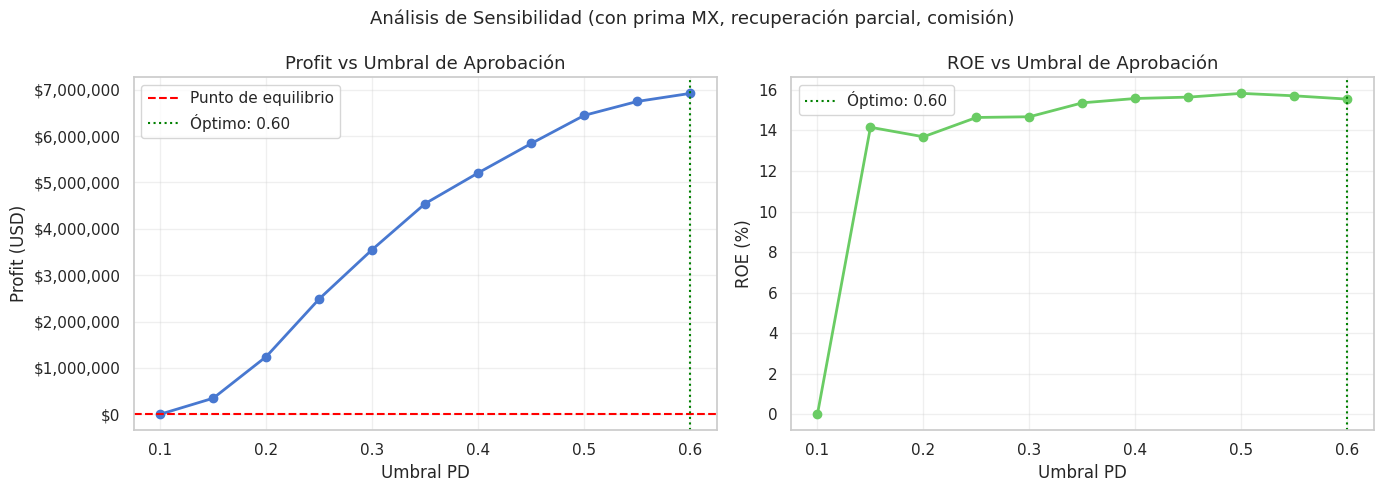


Umbral óptimo: 60% → Profit: $6,922,627 USD | ROE: 15.54%


In [23]:
# ============================================================
# ANÁLISIS DE SENSIBILIDAD — ¿Cuál umbral maximiza el profit?
# ============================================================
umbrales = np.arange(0.10, 0.65, 0.05)
resultados_sens = []

for u in umbrales:
    aprobados_u = df_sim[df_sim['pd'] < u].copy()
    if len(aprobados_u) == 0:
        resultados_sens.append({'umbral': u, 'profit': 0, 'n': 0, 'roe': 0})
        continue

    aprobados_u['monto'] = np.where(aprobados_u['pd'] < 0.15,
                                     aprobados_u['costo_usd'],
                                     aprobados_u['costo_usd'] * 0.80)

    pagaron_u = aprobados_u[aprobados_u['pago_real'] == 'Sí']
    defaults_u = aprobados_u[aprobados_u['pago_real'] == 'No']

    # Ingresos
    ing_intereses = (pagaron_u['monto'] * pagaron_u['tasa_anual']).sum()
    ing_comisiones = aprobados_u['monto'].sum() * COMISION_APERTURA

    # Recuperación parcial de defaults (promedio 50%)
    pct_recup = 0.50
    ing_recuperacion = (defaults_u['monto'] * pct_recup).sum()
    ing_int_parcial = (defaults_u['monto'] * defaults_u['tasa_anual'] * pct_recup).sum()

    # Egresos
    perdida_bruta = defaults_u['monto'].sum()
    costo_seg = aprobados_u['monto'].sum() * TASA_SEGURO

    prof = ing_intereses + ing_comisiones + ing_recuperacion + ing_int_parcial - perdida_bruta - costo_seg
    monto_t = aprobados_u['monto'].sum()
    resultados_sens.append({
        'umbral': u, 'profit': prof,
        'n': len(aprobados_u), 'roe': prof/monto_t*100 if monto_t > 0 else 0
    })

df_sens = pd.DataFrame(resultados_sens)
umbral_opt = df_sens.loc[df_sens['profit'].idxmax(), 'umbral']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_sens['umbral'], df_sens['profit'], 'b-o', linewidth=2)
axes[0].axhline(0, color='red', linestyle='--', label='Punto de equilibrio')
axes[0].axvline(umbral_opt, color='green', linestyle=':', label=f'Óptimo: {umbral_opt:.2f}')
axes[0].set_xlabel('Umbral PD'); axes[0].set_ylabel('Profit (USD)')
axes[0].set_title('Profit vs Umbral de Aprobación')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].plot(df_sens['umbral'], df_sens['roe'], 'g-o', linewidth=2)
axes[1].axvline(umbral_opt, color='green', linestyle=':', label=f'Óptimo: {umbral_opt:.2f}')
axes[1].set_xlabel('Umbral PD'); axes[1].set_ylabel('ROE (%)')
axes[1].set_title('ROE vs Umbral de Aprobación')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Análisis de Sensibilidad (con prima MX, recuperación parcial, comisión)', fontsize=13)
plt.tight_layout(); plt.show()

print(f'\nUmbral óptimo: {umbral_opt:.0%} → Profit: ${df_sens.loc[df_sens["profit"].idxmax(), "profit"]:,.0f} USD | ROE: {df_sens.loc[df_sens["profit"].idxmax(), "roe"]:.2f}%')


### 9.5 Visualizaciones del portafolio simulado

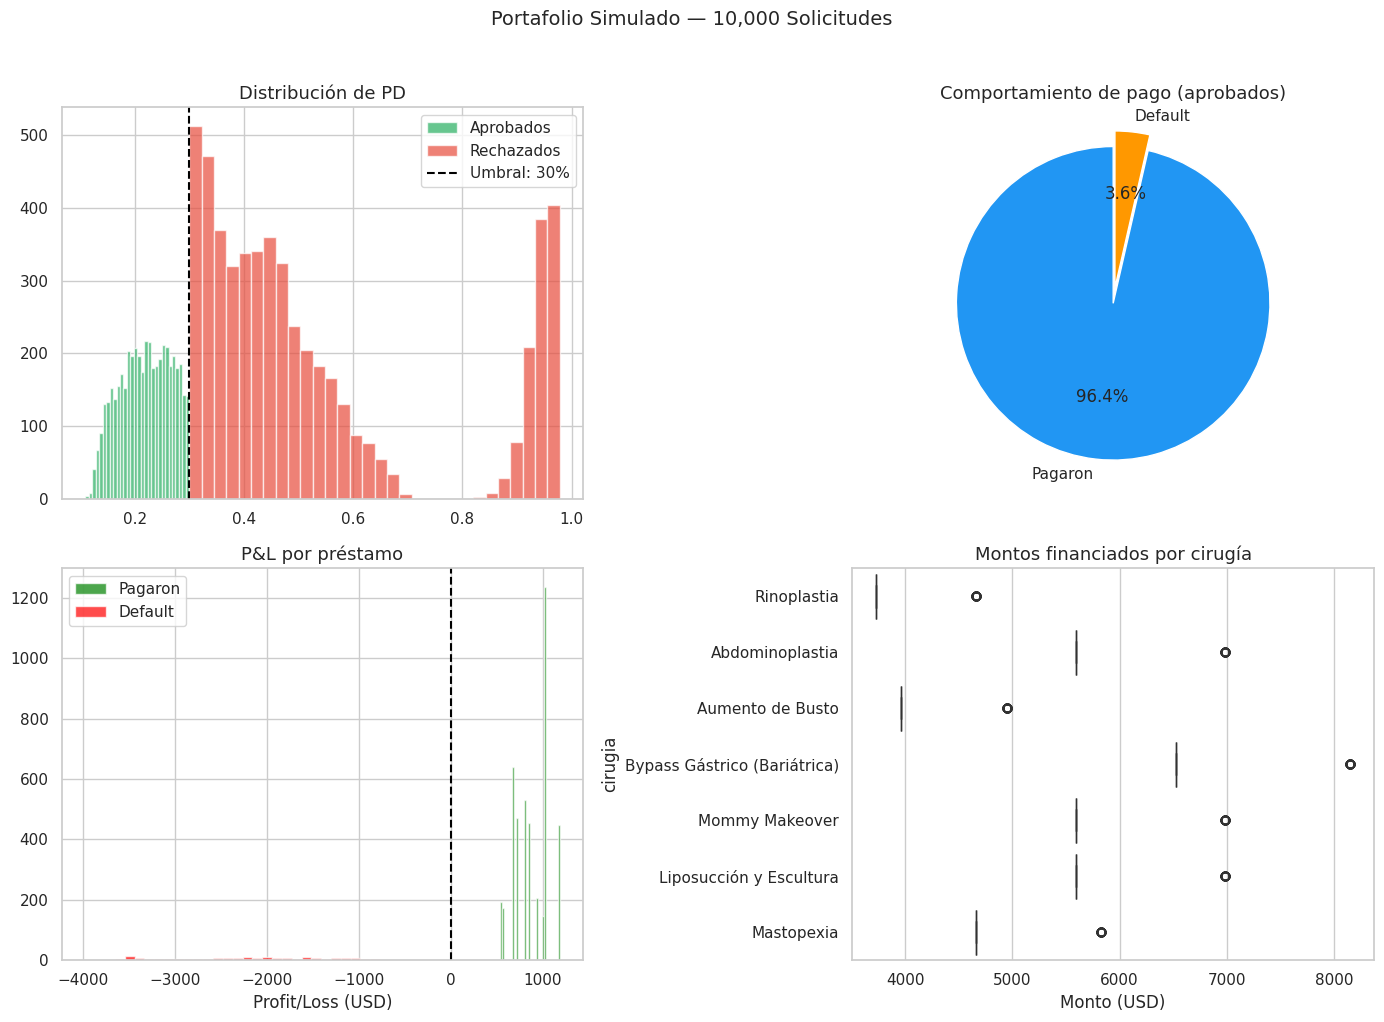

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de PD (aprobados vs rechazados)
axes[0,0].hist(df_aprob['pd'], bins=30, alpha=0.7, color='#27ae60', label='Aprobados', edgecolor='white')
axes[0,0].hist(df_rech['pd'], bins=30, alpha=0.7, color='#e74c3c', label='Rechazados', edgecolor='white')
axes[0,0].axvline(UMBRAL_PD, color='black', linestyle='--', label=f'Umbral: {UMBRAL_PD:.0%}')
axes[0,0].set_title('Distribución de PD'); axes[0,0].legend()

# 2. Pagaron vs No pagaron (pie chart)
conteo = df_aprob['pago_real'].value_counts()
axes[0,1].pie(conteo.values, labels=['Pagaron', 'Default'], autopct='%1.1f%%',
              colors=['#2196F3', '#FF9800'], startangle=90, explode=(0, 0.1))
axes[0,1].set_title('Comportamiento de pago (aprobados)')

# 3. P&L por préstamo (histograma)
axes[1,0].hist(df_aprob[df_aprob['pago_real']=='Sí']['pnl_neto'], bins=30,
               alpha=0.7, color='green', label='Pagaron', edgecolor='white')
axes[1,0].hist(df_aprob[df_aprob['pago_real']=='No']['pnl_neto'], bins=30,
               alpha=0.7, color='red', label='Default', edgecolor='white')
axes[1,0].axvline(0, color='black', linestyle='--')
axes[1,0].set_title('P&L por préstamo'); axes[1,0].legend()
axes[1,0].set_xlabel('Profit/Loss (USD)')

# 4. Monto por tipo de cirugía (boxplot)
sns.boxplot(data=df_aprob, x='monto_usd', y='cirugia', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Montos financiados por cirugía')
axes[1,1].set_xlabel('Monto (USD)')

plt.suptitle(f'Portafolio Simulado — {N_SIM:,} Solicitudes', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


---
## Conclusiones

### Modelo de riesgo
- Los modelos PD (Regresión Logística y Random Forest) obtuvieron AUC ~0.72, dentro del benchmark de la industria.
- La validación cruzada 5-fold confirmó estabilidad (±0.004 de varianza).
- El LGD mediano de 1.0 refleja la naturaleza estructural del crédito al consumo no garantizado.
- Un banco podría implementar la Regresión Logística sin perder poder predictivo, ganando interpretabilidad regulatoria.

### Aplicación a cirugías plásticas
- El simulador individual (7 pacientes) demuestra el flujo operativo completo: evaluación → grade → tasa → mensualidad → decisión.
- La simulación masiva (10,000 solicitudes) permite estimar P&L, ROE y el umbral óptimo de aprobación.
- El análisis de sensibilidad identifica el punto donde se maximiza el profit sin asumir riesgo excesivo.

### Supuestos y limitaciones
1. El modelo fue entrenado con datos de EE.UU. (2007-2015). En producción, debería reentrenarse con datos del mercado mexicano.
2. El LGD promedio de ~0.94 es conservador; datos propios de recuperación lo refinarían.
3. Los precios de cirugías son promedios de Guadalajara y varían por clínica.
4. El seguro de vida de $4,000 MXN es un estimado basado en primas de MAPFRE, BBVA y GNP.
5. El plazo fijo de 12 meses limita el mercado; plazos de 18-24 meses ampliarían la base de clientes.
6. `class_weight='balanced'` infla las probabilidades absolutas de PD; las métricas discriminantes (AUC, Gini, KS) no se ven afectadas.
